# 04_qc_adata

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import scanpy as sc
from pathlib import Path

In [24]:
import pybiomart
from pybiomart import Server

server = Server(host='http://www.ensembl.org')
mart = server['ENSEMBL_MART_ENSEMBL']['mmusculus_gene_ensembl']

In [28]:
# Query unwanted biotypes all at once
unwanted_biotypes = [
    'rRNA', 'rRNA_pseudogene', 'Mt_rRNA',
    'snRNA', 'snoRNA',          # optional, if you want small RNAs too
    'misc_RNA'                  # catches n-R5s and similar
]

unwanted_genes = mart.query(
    attributes=['mgi_symbol', 'gene_biotype'],
    filters={'biotype': unwanted_biotypes}
)

unwanted_set = set(unwanted_genes['MGI symbol'].dropna())

In [29]:
adata = sc.read_h5ad(f"/home/unix/cchu/projects/ZmanR/pqe/results/04/zmanseq.h5ad")

In [30]:
adata

AnnData object with n_obs × n_vars = 43392 × 52634
    obs: 'well_coordinates', 'Amp_batch_ID', 'Subject_ID', 'Number_of_cells', 'Seq_batch_ID', 'Pool_barcode', 'Pool_barcode_i5', 'Cell_barcode', 'Mouse', 'time_assignment', 'cluster_colors', 'sc_x', 'sc_y', 'Treatment'

> We first removed specific mitochondrial genes, immunoglobulin genes, ribosomal genes, and genes linked with poorly supported transcriptional models (such as those annotated with the suffix ‘‘Rik’’ and so on). We also discarded cells with less than 300 UMIs from the subsequent analysis (Kirschenbaum, Xie, Ingelfinger, 2024, Cell)

In [ ]:
import re

pattern = re.compile(
    r'^Rpl|^Rps|^mt-|^Igh|^Igk|^Igl|Rik$|^Gm\d|^AK\d|^AY\d|^BC\d|^BG\d|^BM\d|^LOC|^EG\d|^ENSMUSG',
    re.IGNORECASE
)
genes_filtered = [g for g in adata.var_names if not pattern.search(g) and g not in unwanted_set]
len(genes_filtered)

27293

In [6]:
fil_adata = adata[:, genes_filtered]

In [7]:
sc.pp.calculate_qc_metrics(fil_adata, inplace=True, log1p=True)


/data/ClaudiaC/envs/zmanr_env/lib/python3.13/site-packages/scanpy/preprocessing/_qc.py:125: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[obs_metrics.columns] = obs_metrics


In [8]:
%matplotlib inline

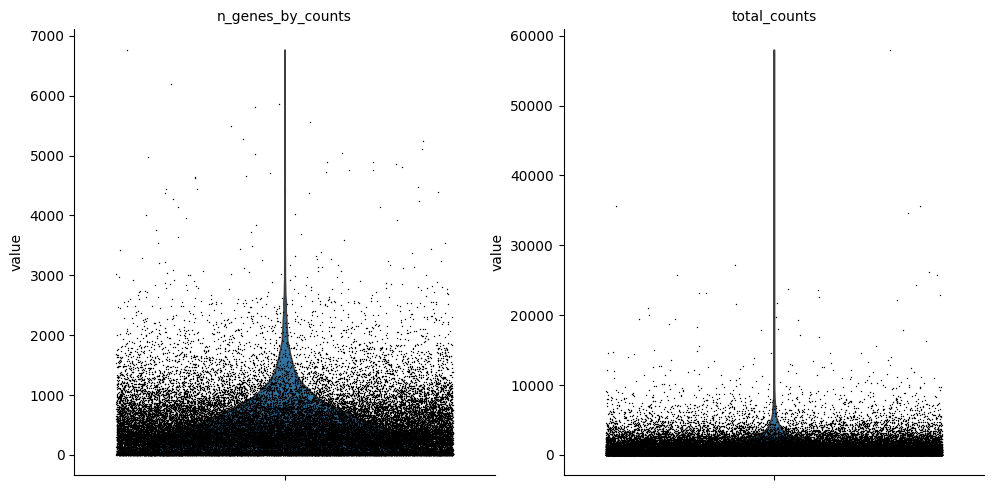

In [9]:
sc.pl.violin(
    fil_adata,
    ["n_genes_by_counts", "total_counts"],
    jitter=0.4,
    multi_panel=True,
)
plt.show()

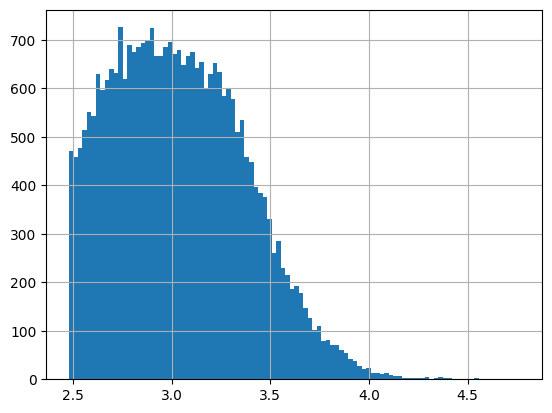

In [10]:
np.log10(fil_adata.obs.query("total_counts > 300")["total_counts"]).hist(bins=100)
plt.show()

In [11]:
final_adata = fil_adata[fil_adata.obs.query("total_counts > 300").index]

In [12]:
sc.pp.calculate_qc_metrics(final_adata, inplace=True, log1p=True)


/data/ClaudiaC/envs/zmanr_env/lib/python3.13/site-packages/scanpy/preprocessing/_qc.py:125: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[obs_metrics.columns] = obs_metrics


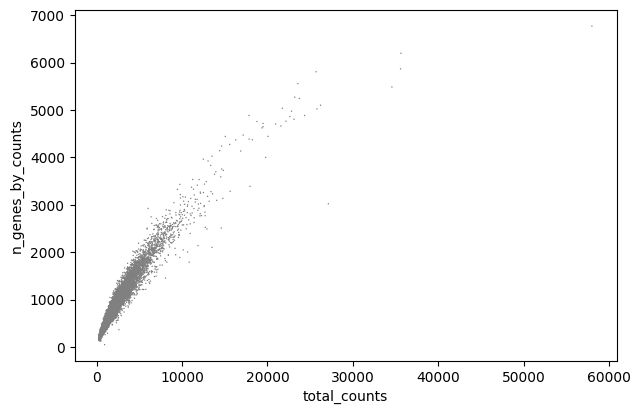

In [13]:
sc.pl.scatter(final_adata, "total_counts", "n_genes_by_counts")


In [14]:
final_adata.var

,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts
1700047I17Rik2,153,0.005337,0.005322,99.479928,157.0,5.062595
1700049E17Rik1,1,0.000034,0.000034,99.996601,1.0,0.693147
2610044O15Rik8,262,0.012747,0.012666,99.109419,375.0,5.929589
2810047C21Rik1,4,0.000136,0.000136,99.986403,4.0,1.609438
9930111J21Rik1,290,0.011523,0.011457,99.014242,339.0,5.828946
...,...,...,...,...,...,...
n-R5s96,2,0.000068,0.000068,99.993202,2.0,1.098612
n-R5s97,0,0.000000,0.000000,100.000000,0.0,0.000000
n-R5s98,0,0.000000,0.000000,100.000000,0.0,0.000000
n-TSaga9,18,0.000714,0.000714,99.938815,21.0,3.091043


Metacells expects raw count matrix

In [15]:
sc.pp.highly_variable_genes(final_adata, n_top_genes=2000, flavor="seurat_v3") # not sure about batch

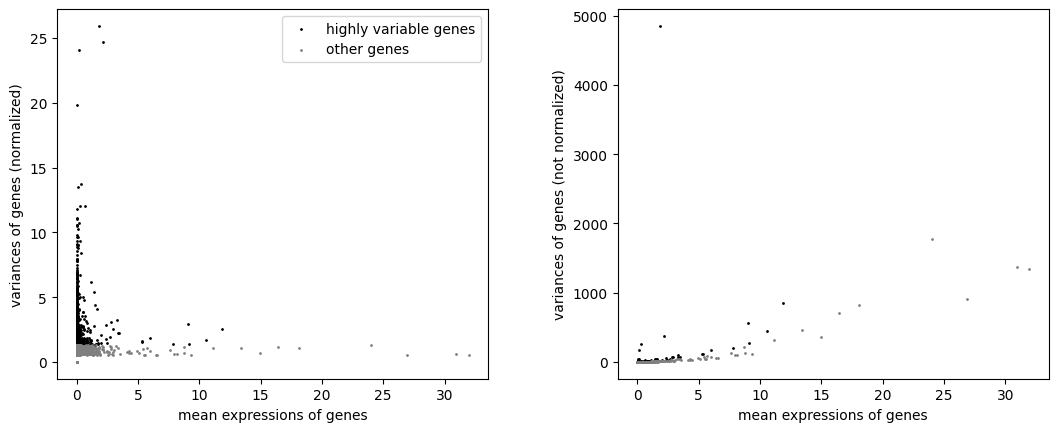

In [16]:
sc.pl.highly_variable_genes(final_adata)


In [17]:
final_adata.var

,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts,highly_variable,highly_variable_rank,means,variances,variances_norm
1700047I17Rik2,153,0.005337,0.005322,99.479928,157.0,5.062595,False,NaN,0.005337,0.005580,0.534725
1700049E17Rik1,1,0.000034,0.000034,99.996601,1.0,0.693147,False,NaN,0.000034,0.000034,1.000068
2610044O15Rik8,262,0.012747,0.012666,99.109419,375.0,5.929589,False,NaN,0.012747,0.023734,0.962676
2810047C21Rik1,4,0.000136,0.000136,99.986403,4.0,1.609438,False,NaN,0.000136,0.000136,0.760016
9930111J21Rik1,290,0.011523,0.011457,99.014242,339.0,5.828946,False,NaN,0.011523,0.016422,0.737146
...,...,...,...,...,...,...,...,...,...,...,...
n-R5s96,2,0.000068,0.000068,99.993202,2.0,1.098612,False,NaN,0.000068,0.000068,0.896513
n-R5s97,0,0.000000,0.000000,100.000000,0.0,0.000000,False,NaN,0.000000,0.000000,0.000000
n-R5s98,0,0.000000,0.000000,100.000000,0.0,0.000000,False,NaN,0.000000,0.000000,0.000000
n-TSaga9,18,0.000714,0.000714,99.938815,21.0,3.091043,False,NaN,0.000714,0.000917,0.753354
